In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("NIFTY50_all.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366.0,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338.0,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121.0,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762.0,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470.0,2.875200e+14,NaN,816123.0,0.2741


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nStocks:")
print(df["Symbol"].nunique())

print("\nDate Range:")
print(df["Date"].min())
print(df["Date"].max())

Rows: 17843
Columns: 15

Stocks:
7

Date Range:
2000-01-03 00:00:00
2021-04-30 00:00:00


In [5]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

,0
Trades,8019
Deliverable Volume,1019
%Deliverble,1019
Last,1
Low,1
High,1
Open,1
Volume,1
VWAP,1
Close,1


In [6]:
df.describe()

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,17843,17843.000000,17842.000000,17842.000000,17842.000000,17842.000000,17842.00000,17842.000000,1.784200e+04,1.784200e+04,9.824000e+03,1.682400e+04,16824.000000
mean,2012-02-06 18:32:44.736871680,1016.577554,1017.376628,1032.148907,1002.172884,1016.745914,1016.79078,1017.296118,2.131898e+06,1.398135e+14,5.858968e+04,9.253217e+05,0.520434
min,2000-01-03 00:00:00,22.150000,21.000000,23.700000,21.000000,22.150000,22.15000,22.170000,2.500000e+01,1.278415e+09,7.000000e+01,2.500000e+01,0.056200
25%,2008-07-01 00:00:00,329.350000,329.900000,335.000000,324.550000,329.500000,329.36250,330.042500,9.871350e+04,5.283434e+12,2.090350e+04,7.191625e+04,0.384800
50%,2012-04-26 00:00:00,612.500000,613.125000,624.400000,597.825000,611.725000,612.55000,612.980000,5.172700e+05,5.266270e+13,3.793600e+04,2.807140e+05,0.513950
75%,2016-10-28 00:00:00,1405.850000,1409.525000,1425.775000,1389.762500,1406.000000,1405.90000,1407.910000,1.981768e+06,1.525118e+14,6.994100e+04,8.811165e+05,0.642600
max,2021-04-30 00:00:00,5213.100000,5221.100000,5247.750000,5150.050000,5221.100000,5213.10000,5175.790000,1.205419e+08,8.160988e+15,1.205984e+06,9.490116e+07,1.000000
std,NaN,966.602235,966.931513,978.023379,956.279755,966.763382,966.81254,967.186686,5.118901e+06,2.830306e+14,6.848194e+04,2.018119e+06,0.188745


In [7]:
df["Symbol"].nunique()

7

In [8]:
stock_counts = (
    df["Symbol"]
    .value_counts()
)

stock_counts.head(20)

,count
Symbol,
ASIANPAINT,5306
AXISBANK,3394
BAJAJ-AUTO,3202
ADANIPORTS,2299
UTIBANK,1912
MUNDRAPORT,1023
BAJAJFINSV,707


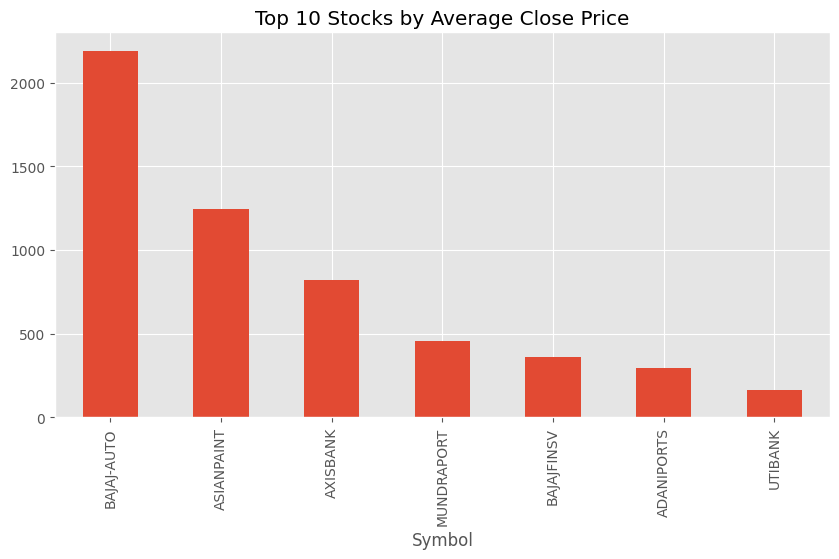

In [9]:
avg_close = (
    df.groupby("Symbol")["Close"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_close.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Stocks by Average Close Price")
plt.show()

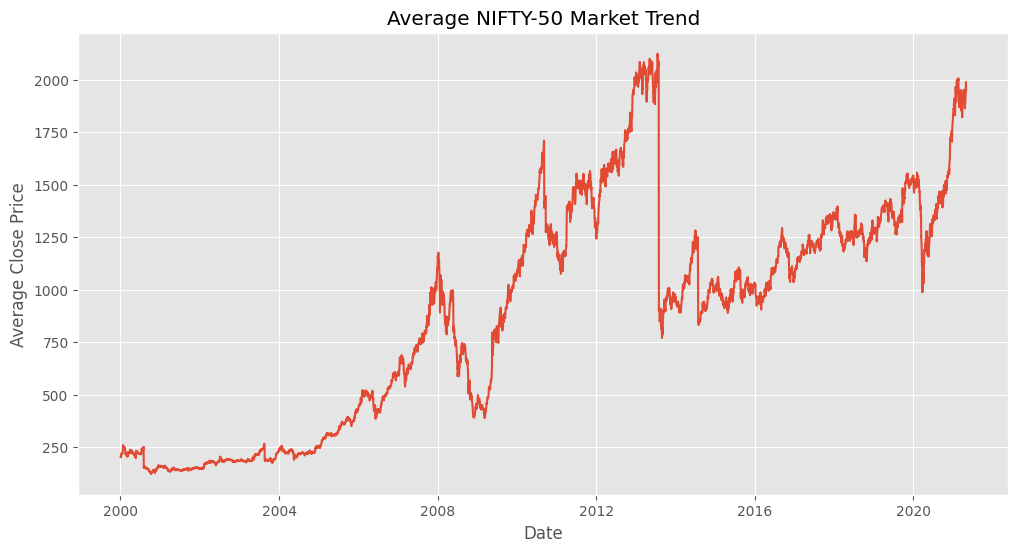

In [10]:
market = (
    df.groupby("Date")["Close"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    market.index,
    market.values
)

plt.title(
    "Average NIFTY-50 Market Trend"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

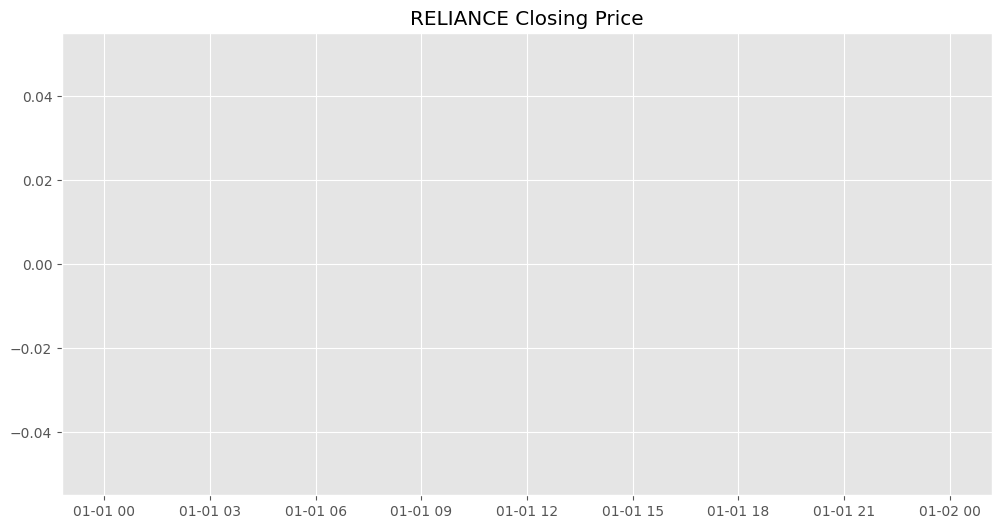

In [11]:
stock = "RELIANCE"

stock_df = (
    df[df["Symbol"] == stock]
    .sort_values("Date")
)

plt.figure(figsize=(12,6))

plt.plot(
    stock_df["Date"],
    stock_df["Close"]
)

plt.title(f"{stock} Closing Price")

plt.show()

In [12]:
stock_df["Return"] = (
    stock_df["Close"]
    .pct_change()
)

stock_df["Return"].describe()

,Return
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


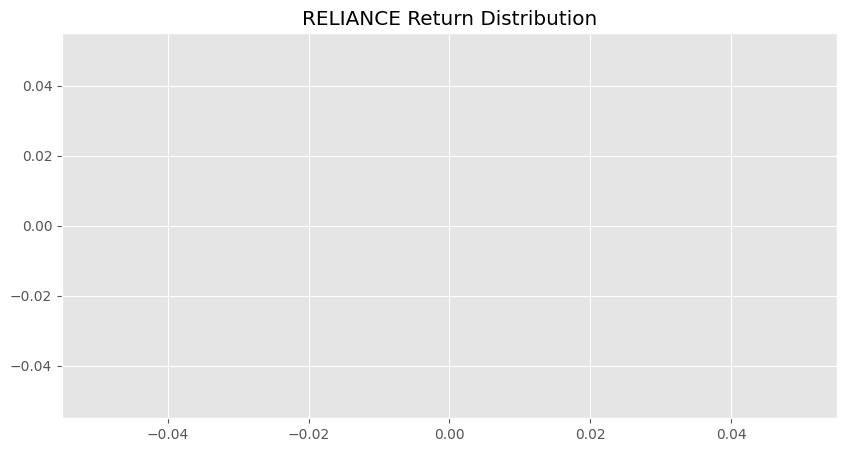

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    stock_df["Return"].dropna(),
    bins=50
)

plt.title(
    f"{stock} Return Distribution"
)

plt.show()

In [14]:
volatility = (
    df.groupby("Symbol")["Close"]
    .apply(
        lambda x:
        x.pct_change().std()
    )
    .sort_values(
        ascending=False
    )
)

volatility.head(10)

/tmp/ipykernel_3244/1902952933.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  x.pct_change().std()


,Close
Symbol,
MUNDRAPORT,0.041174
BAJAJFINSV,0.034427
UTIBANK,0.031482
AXISBANK,0.029973
ADANIPORTS,0.024048
ASIANPAINT,0.022355
BAJAJ-AUTO,0.021345


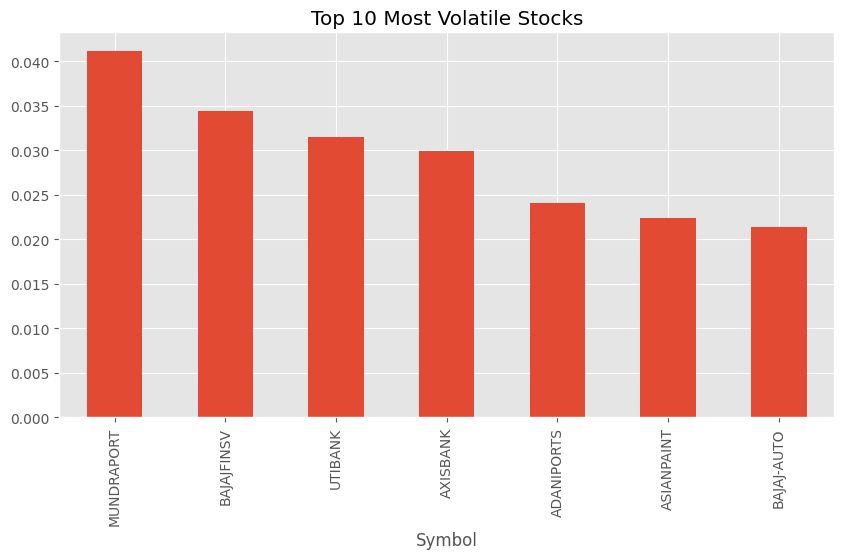

In [15]:
volatility.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Most Volatile Stocks"
)

plt.show()

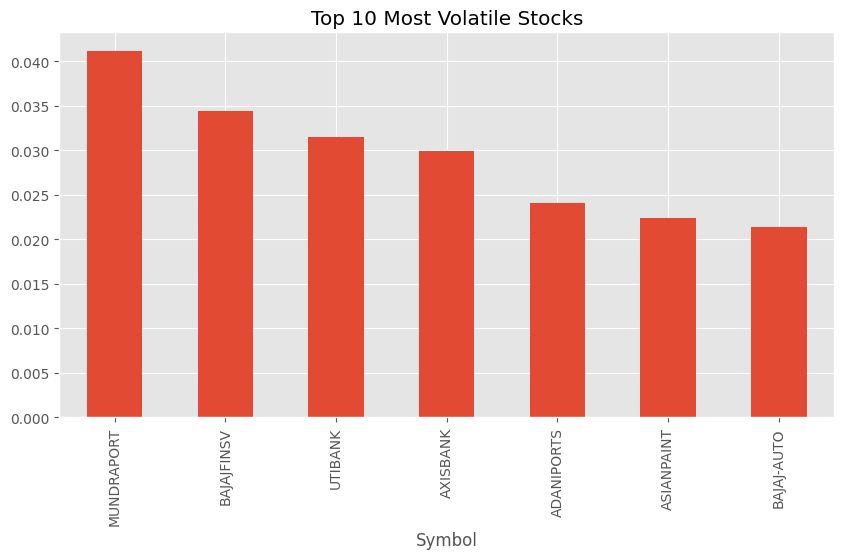

In [16]:
volatility.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Most Volatile Stocks"
)

plt.show()

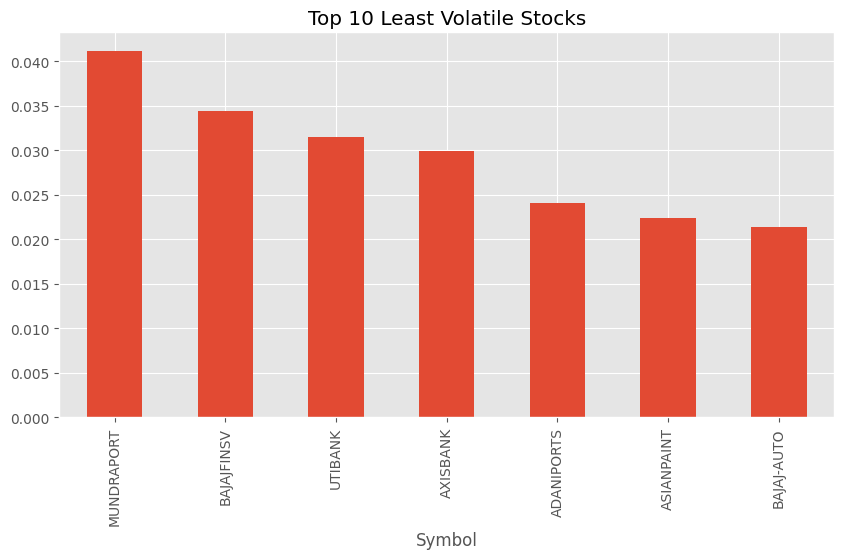

In [17]:
volatility.tail(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Least Volatile Stocks"
)

plt.show()

/tmp/ipykernel_3244/1364061054.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  pivot.pct_change()


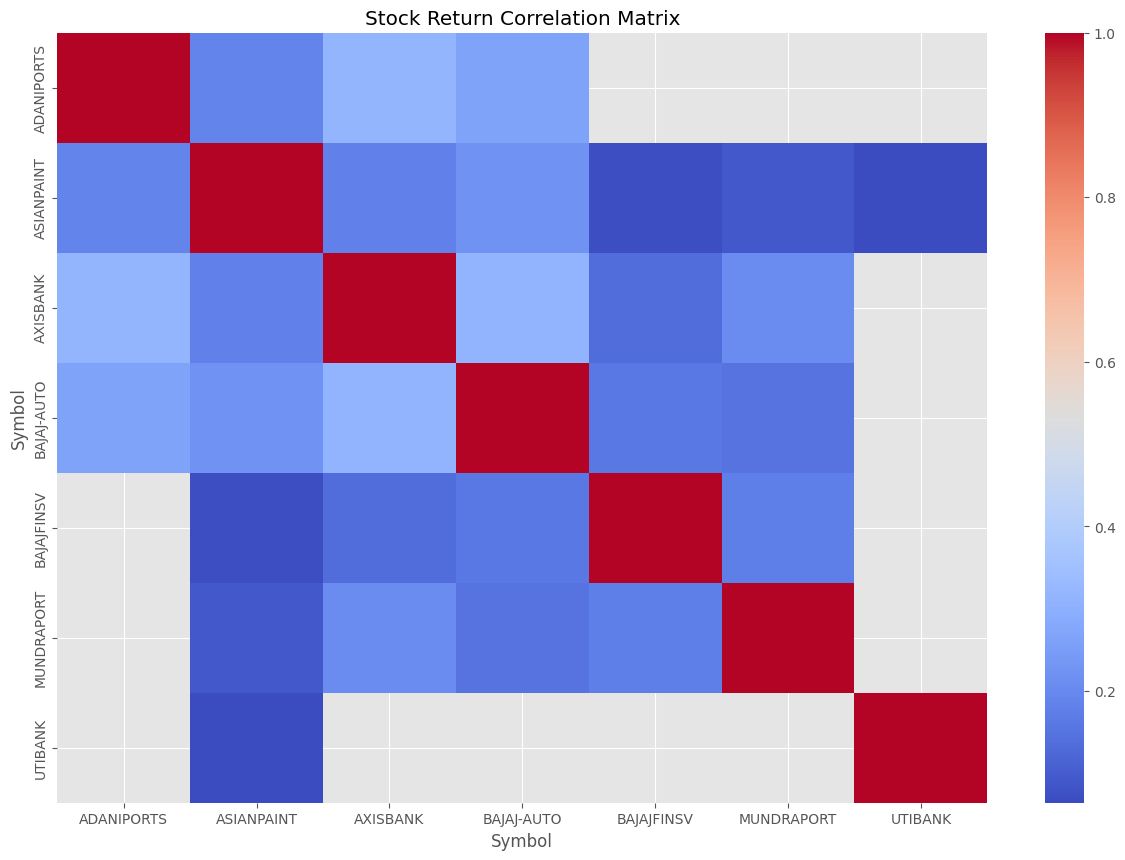

In [19]:
pivot = df.pivot_table(
    index="Date",
    columns="Symbol",
    values="Close"
)

returns = (
    pivot.pct_change()
)

corr = returns.corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Stock Return Correlation Matrix"
)

plt.show()

In [20]:
performance = {}

for stock in df["Symbol"].unique():

    temp = (
        df[df["Symbol"] == stock]
        .sort_values("Date")
    )

    start = temp["Close"].iloc[0]
    end = temp["Close"].iloc[-1]

    performance[stock] = (
        (end - start)
        / start
    )

performance = pd.Series(
    performance
).sort_values(
    ascending=False
)

performance.head(10)

,0
UTIBANK,21.378277
ASIANPAINT,5.645880
BAJAJ-AUTO,5.339396
ADANIPORTS,4.214643
AXISBANK,0.281527
MUNDRAPORT,-0.859279
BAJAJFINSV,NaN


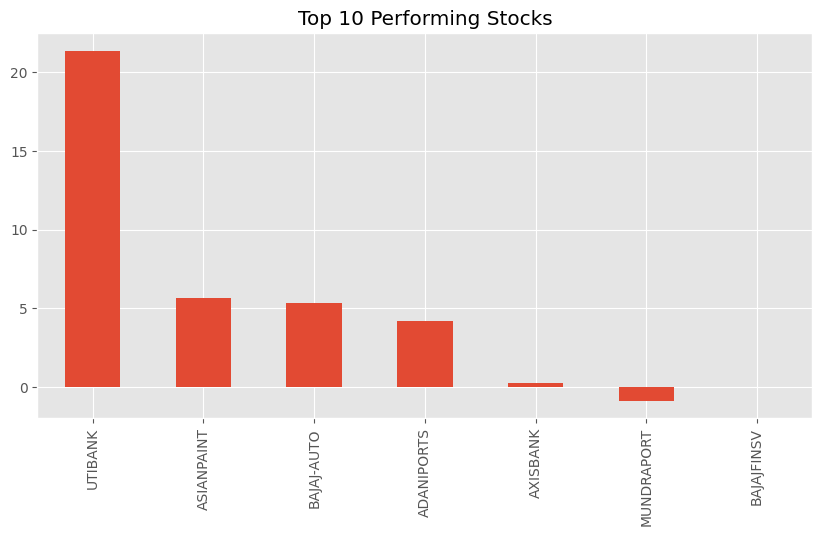

In [21]:
performance.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Performing Stocks"
)

plt.show()

In [22]:
print("Key EDA Insights")

print(
    f"Total Stocks: {df['Symbol'].nunique()}"
)

print(
    f"Date Range: {df['Date'].min()} to {df['Date'].max()}"
)

print(
    f"Best Performing Stock: {performance.index[0]}"
)

print(
    f"Most Volatile Stock: {volatility.index[0]}"
)

Key EDA Insights
Total Stocks: 7
Date Range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Best Performing Stock: UTIBANK
Most Volatile Stock: MUNDRAPORT
